# B2B Buyer Propensity Model

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
file_path = '/content/drive/MyDrive/Snowflake/DS_Sample_Data.xlsx'

In [ ]:
# Load the 'train' sheet
df_train = pd.read_excel(file_path, sheet_name='train')
print("Train Sheet:")
display(df_train.head())

# Load the 'test' sheet
df_test = pd.read_excel(file_path, sheet_name='test')
print("\nTest Sheet:")
display(df_test.head())

Train Sheet:


,DATASET,TARGET,ACCOUNT_ID,SALES_GEO,PRODUCT_FIT_SCORE,DEAL_COMPLEXITY,HAS_INTERNAL_CHAMPION,ENGAGEMENT_SCORE,REVENUE_RANGE,EMPLOYEE_COUNT,...,MARKETING_EMPLOYEES_RANGE,OPEN_JOB_POSTS_RANGE,ESTIMATED_MONTHLY_IT_SPEND_RANGE,LINKEDIN_FOLLOWERS_RANGE,PUBLIC_PRIVATE_COMPANY,INDUSTRY,IS_VALID_WEBSITE,IS_USING_CLOUD_TECHNOLOGY,HAS_OFFICES_IN_MULTIPLE_LOCATIONS,LINKED_FOLLOWER_RANGE
0,train,1,46f19851053b146305d72bfbe5c4f62de32cd2941dc2d5...,APJ,68,Low,0,62,$10M-$50M,500-999,...,50-199,21-50,<$10K,<1K,Unknown,Unknown,True,1.0,0.0,<1K
1,train,1,52a1c89b31df676fed6168afbbbf699ddfb1f286df6857...,Americas,36,Medium,1,42,<$10M,<10,...,0,0,<$10K,<1K,Unknown,Unknown,True,0.0,0.0,<1K
2,train,1,26e0f5374b1faba5bb972a98965b88ec083e58dad3aba5...,APJ,50,Low,0,82,$50M-$100M,500-999,...,10-49,2026-01-05 00:00:00,$50K-$100K,<1K,Privately owned,Financial Services,True,1.0,0.0,<1K
3,train,1,1fa9d424f1576e19a30999af8458a461e9d94dbb7ca498...,Americas,44,Low,1,73,$250M-$500M,1K-4.9K,...,10-49,21-50,$10K-$50K,10K-49.9K,Unknown,Consulting & Professional Services,True,1.0,1.0,10K-49.9K
4,train,1,94a39f77f4819fcdf6856e0b347a302ef07a90913316d1...,APJ,81,Medium,0,69,>$1B,5K-9.9K,...,10-49,0,$100K-$250K,<1K,Unknown,Retail & Consumer Goods,True,1.0,0.0,<1K



Test Sheet:


,DATASET,ACCOUNT_ID,SALES_GEO,PRODUCT_FIT_SCORE,DEAL_COMPLEXITY,HAS_INTERNAL_CHAMPION,ENGAGEMENT_SCORE,REVENUE_RANGE,EMPLOYEE_COUNT,DATA_ANALYTICS_EMPLOYEES_RANGE,...,MARKETING_EMPLOYEES_RANGE,OPEN_JOB_POSTS_RANGE,ESTIMATED_MONTHLY_IT_SPEND_RANGE,LINKEDIN_FOLLOWERS_RANGE,PUBLIC_PRIVATE_COMPANY,INDUSTRY,IS_VALID_WEBSITE,IS_USING_CLOUD_TECHNOLOGY,HAS_OFFICES_IN_MULTIPLE_LOCATIONS,LINKED_FOLLOWER_RANGE
0,test,75ee65bd7b2c855bb6d2624f59c91ce8e72db879e582fd...,EMEA,65,Medium,0,39,$250M-$500M,500-999,0,...,2026-01-09 00:00:00,2026-01-05 00:00:00,$10K-$50K,1K-4.9K,Privately owned,Financial Services,True,1.0,0.0,1K-4.9K
1,test,93078f10242fec60fbaff5d56aeb91b4d5436771db1264...,APJ,35,Low,0,81,$50M-$100M,200-499,2026-01-09 00:00:00,...,10-49,0,<$10K,<1K,Unknown,Financial Services,True,0.0,0.0,<1K
2,test,cafd9546a85b8f322b712a9526548bf9375f10f4537aba...,EMEA,64,Low,0,28,<$10M,10-49,2026-01-09 00:00:00,...,2026-01-09 00:00:00,2026-01-05 00:00:00,<$10K,<1K,Unknown,Unknown,True,0.0,0.0,<1K
3,test,6b2cf13ba0048aafcc5756890e56d47999cfbcdc74b126...,EMEA,77,Medium,0,38,>$1B,500-999,0,...,2026-01-09 00:00:00,2026-01-05 00:00:00,<$10K,<1K,Privately owned,Manufacturing & Industrial,True,1.0,0.0,<1K
4,test,157e50d605e1ca9ff328e16fe19eb9982348cc1dc7a2ea...,Americas,63,Low,1,45,<$10M,10-49,2026-01-09 00:00:00,...,0,0,<$10K,<1K,Privately owned,Technology,True,1.0,0.0,<1K


### 1.0 Strategic Framework & Hypotheses
Before analyzing the data, we established three core hypotheses to guide our modeling strategy:

1.  **Capacity Hypothesis (Firmographics):** Larger companies (Revenue/Employees) have higher purchasing power but are rarer. We expect these features to be highly skewed (Power Law).
2.  **Intent Hypothesis (Behavior):** Engagement is a proxy for intent. We expect `ENGAGEMENT_SCORE` to be the strongest differentiator between Buyers and Non-Buyers.
3.  **Fit Hypothesis (Product):** Technical compatibility (`PRODUCT_FIT_SCORE`) acts as a "gatekeeper." High engagement without product fit likely leads to a lost deal.

## 1. Exploratory Data Analysis

In [ ]:
print(f"Training Data Shape: {df_train.shape}")
print(f"Test Data Shape: {df_test.shape}")

Training Data Shape: (10000, 23)
Test Data Shape: (10000, 22)


### 1.1) Inspect class Imbalance

Class Distribution (%):
TARGET
0    90.0
1    10.0
Name: proportion, dtype: float64


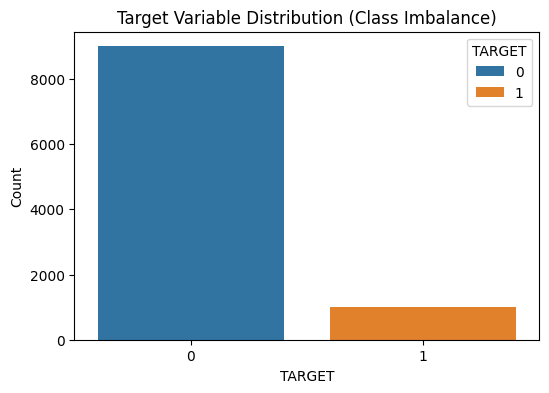

In [ ]:
target_counts = df_train['TARGET'].value_counts(normalize=True) * 100
print(f"Class Distribution (%):\n{target_counts}")

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET', data=df_train, hue='TARGET')
plt.title('Target Variable Distribution (Class Imbalance)')
plt.ylabel('Count')
plt.show()


**Observation:**
The dataset exhibits a severe **90:10 class imbalance** (10% Buyers vs. 90% Non-Buyers).
* **Implication:** A model predicting "No" for every account would achieve 90% accuracy but 0% value.
* **Strategy:** We will address this using **Stratified Splitting** during validation and **Class Weighting** inside the model to penalize missing the minority class.

### 1.2 Inspect Feature Distributions
We analyze the distribution of key numerical features to understand their shape and identify outliers.

**Key Observations:**
* **Skewed Firmographics:** `REVENUE_RANGE` and `EMPLOYEE_COUNT` likely follow a "Power Law" distribution (mostly small companies, few large ones). This confirms that tree-based models (like Random Forest) are preferable to linear models which struggle with skewed data.
* **Normal Behavior:** `ENGAGEMENT_SCORE` and `PRODUCT_FIT_SCORE` likely follow a normal distribution, making them excellent standardized predictors.

/tmp/ipython-input-965505414.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='REVENUE_RANGE', data=df, order=df['REVENUE_RANGE'].value_counts().index, palette='Blues_r')
/tmp/ipython-input-965505414.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='EMPLOYEE_COUNT', data=df, order=df['EMPLOYEE_COUNT'].value_counts().index, palette='Greens_r')


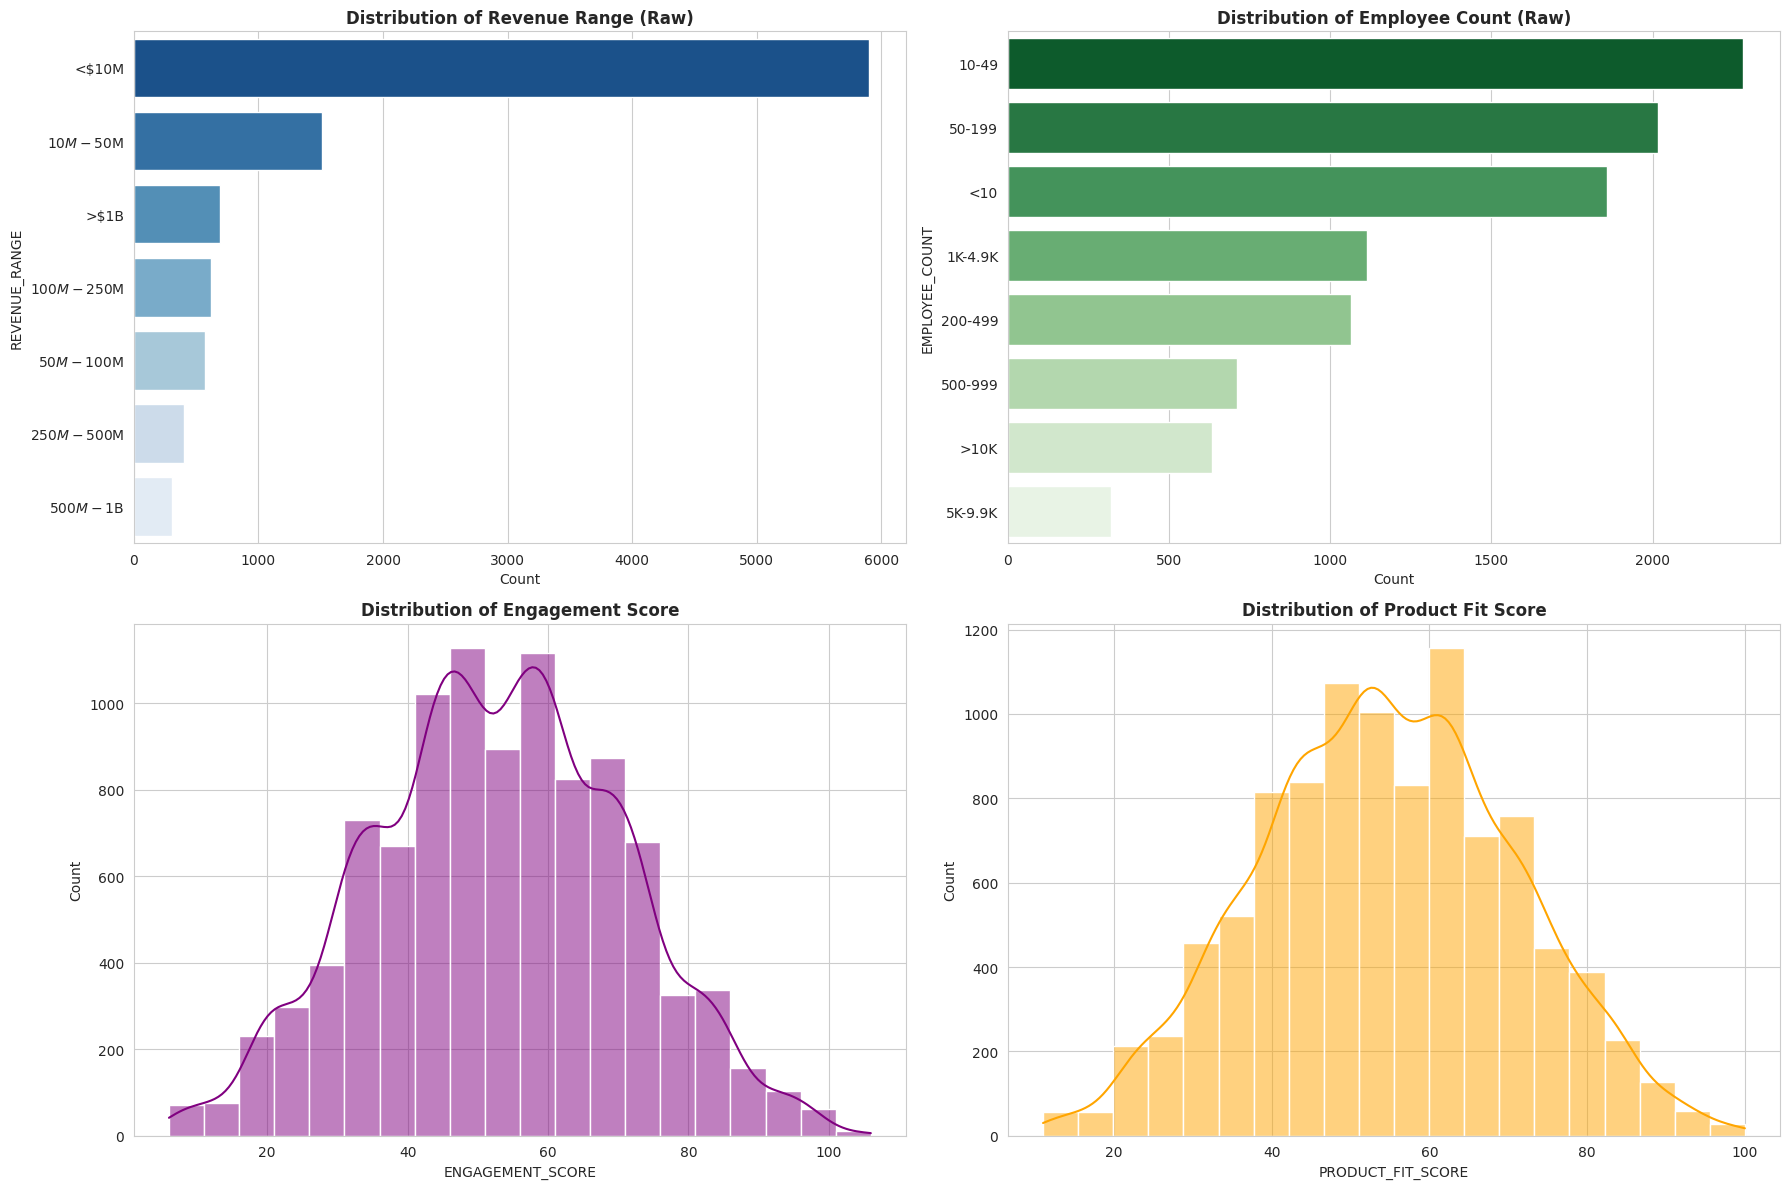

In [ ]:
# Setting up the figure
plt.figure(figsize=(18, 12))
sns.set_style('whitegrid')

# Use df_train consistently (instead of making a copy 'df')
df = df_train

# 1. REVENUE_RANGE (Categorical -> Bar Chart)
plt.subplot(2, 2, 1)
sns.countplot(y='REVENUE_RANGE', data=df, order=df['REVENUE_RANGE'].value_counts().index, palette='Blues_r')
plt.title('Distribution of Revenue Range (Raw)', fontsize=12, fontweight='bold')
plt.xlabel('Count')

# 2. EMPLOYEE_COUNT (Categorical -> Bar Chart)
plt.subplot(2, 2, 2)
sns.countplot(y='EMPLOYEE_COUNT', data=df, order=df['EMPLOYEE_COUNT'].value_counts().index, palette='Greens_r')
plt.title('Distribution of Employee Count (Raw)', fontsize=12, fontweight='bold')
plt.xlabel('Count')

# 3. ENGAGEMENT_SCORE (Numerical -> Histogram)
plt.subplot(2, 2, 3)
sns.histplot(df['ENGAGEMENT_SCORE'], bins=20, kde=True, color='purple')
plt.title('Distribution of Engagement Score', fontsize=12, fontweight='bold')

# 4. PRODUCT_FIT_SCORE (Numerical -> Histogram)
plt.subplot(2, 2, 4)
sns.histplot(df['PRODUCT_FIT_SCORE'], bins=20, kde=True, color='orange')
plt.title('Distribution of Product Fit Score', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Why these specific features?**
We prioritized the visualization of these four features because they represent the primary drivers of B2B propensity:

1.  **Firmographics (Capacity):** `REVENUE_RANGE` and `EMPLOYEE_COUNT` indicate the size of the account. In B2B, larger companies often have higher budgets but longer sales cycles. We need to verify if these features follow a "Power Law" distribution (highly skewed).
2.  **Behavioral Signals (Intent):** `ENGAGEMENT_SCORE` and `PRODUCT_FIT_SCORE` are direct indicators of customer interest and technical compatibility. These are typically the strongest predictors of conversion.

*Note: Other categorical features like `INDUSTRY` or `SALES_GEO` are valuable for segmentation but are secondary to these core signal drivers.*

### 1.3 Identify Missing Values
We inspect the dataset for null values to determine the appropriate imputation strategy.

--- Missing Values Summary ---


,Missing Count,Percentage (%)
HAS_OFFICES_IN_MULTIPLE_LOCATIONS,785,7.85
IS_USING_CLOUD_TECHNOLOGY,589,5.89


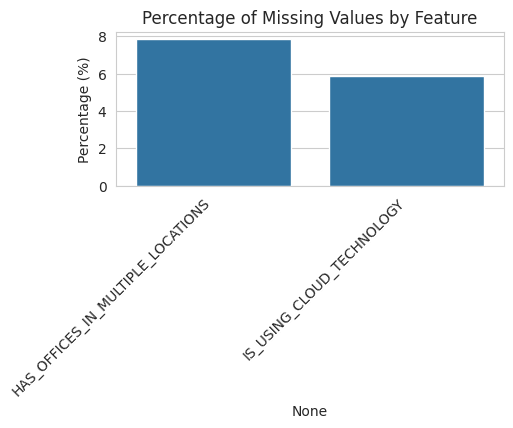

In [ ]:
# Calculate missing values
missing = df_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# Calculate percentage
missing_percent = (missing / len(df_train)) * 100

# Create a DataFrame for cleaner display
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_percent})

print("--- Missing Values Summary ---")
if not missing_df.empty:
    display(missing_df)

    # Visualizing Missing Data
    plt.figure(figsize=(5, 2))
    sns.barplot(x=missing_percent.index, y=missing_percent.values)
    plt.title('Percentage of Missing Values by Feature', fontsize=12)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print("No missing values found in the training set!")

**Key Observations:**
* **Technical Flags:** `IS_USING_CLOUD_TECHNOLOGY` and `HAS_OFFICES_IN_MULTIPLE_LOCATIONS` have significant missing values.
* **Assumption:** In B2B data, missing boolean flags often imply **"False"** (the information wasn't found because it doesn't exist). We will impute these with `0` in the preprocessing step.
* **Data Integrity:** Core fields like `REVENUE_RANGE` and `EMPLOYEE_COUNT` are fully populated, which is excellent for model stability.

In [ ]:
# --- Define Cleaning Function ---
def fill_missing_binary_values(df):
    """
    Fills missing values with 0 for specific binary/boolean columns.
    """
    # List of columns where NaN implies 'False' or 0
    cols_to_fill_zero = ['IS_USING_CLOUD_TECHNOLOGY', 'HAS_OFFICES_IN_MULTIPLE_LOCATIONS']

    for col in cols_to_fill_zero:
        if col in df.columns:
            # Fill NaN with 0
            df[col] = df[col].fillna(0)

    return df

# --- Apply to Both Train and Test ---
print("Imputing missing values...")

df_train = fill_missing_binary_values(df_train)
df_test = fill_missing_binary_values(df_test)

# --- Verification ---
print("\nMissing values after cleaning:")
cols_to_check = ['IS_USING_CLOUD_TECHNOLOGY', 'HAS_OFFICES_IN_MULTIPLE_LOCATIONS']

print("Train Set:")
print(df_train[cols_to_check].isnull().sum())

print("\nTest Set:")
print(df_test[cols_to_check].isnull().sum())

Imputing missing values...

Missing values after cleaning:
Train Set:
IS_USING_CLOUD_TECHNOLOGY            0
HAS_OFFICES_IN_MULTIPLE_LOCATIONS    0
dtype: int64

Test Set:
IS_USING_CLOUD_TECHNOLOGY            0
HAS_OFFICES_IN_MULTIPLE_LOCATIONS    0
dtype: int64


### 1.4 Identifying Noisy Features
We scan for "Noise"—data that increases complexity without adding predictive power. This includes:
1.  **Duplicate Columns:** Features like `LINKEDIN` and `LINKED_FOLLOWER` that might be identical copies of each other.
2.  **Constant Features:** Columns where 100% of rows have the same value (e.g., if everyone is from the 'USA', the column provides zero signal).
3.  **High-Cardinality Identifiers:** Administrative columns like `ACCOUNT_ID` that are unique to every row and cannot be used for patterns.

--- Noise Report ---
Number of Duplicate Account IDs: 0
Number of Exact Duplicate Rows:  0
Constant Columns identified:     ['DATASET']


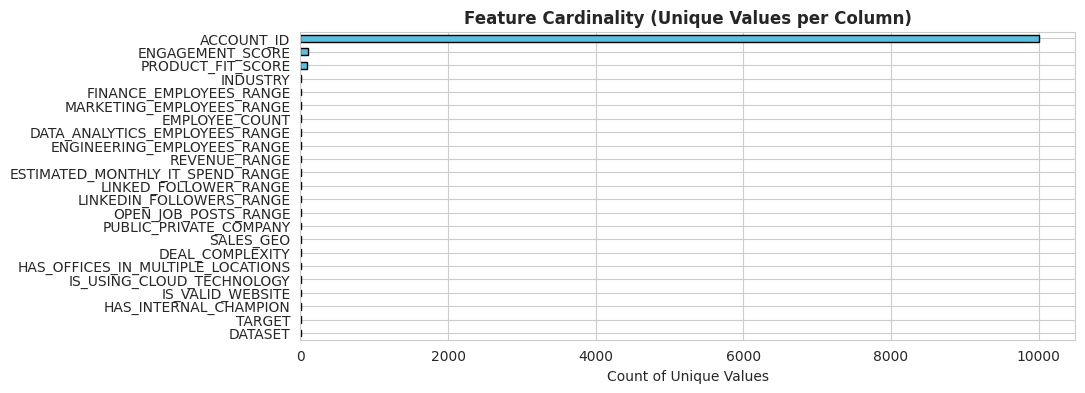

In [ ]:
# 1. Check for Duplicate Account IDs
dup_ids = df_train.duplicated(subset=['ACCOUNT_ID']).sum()

# 2. Check for exact duplicate rows (all columns identical)
dup_rows = df_train.duplicated().sum()

# 3. Check for Constant (Zero-Variance) Features
# We identify columns where only 1 unique value exists
constant_cols = [col for col in df_train.columns if df_train[col].nunique() <= 1]

print("--- Noise Report ---")
print(f"Number of Duplicate Account IDs: {dup_ids}")
print(f"Number of Exact Duplicate Rows:  {dup_rows}")
print(f"Constant Columns identified:     {constant_cols}")

# Professional Visualization of Feature Uniqueness
plt.figure(figsize=(10, 4))
unique_counts = df_train.nunique().sort_values()
unique_counts.plot(kind='barh', color='#5bc0de', edgecolor='black')
plt.title('Feature Cardinality (Unique Values per Column)', fontsize=12, fontweight='bold')
plt.xlabel('Count of Unique Values')
plt.show()

--- Duplicate Column Report ---
Found 1 pairs of duplicate columns:
 - 'LINKED_FOLLOWER_RANGE' is identical to 'LINKEDIN_FOLLOWERS_RANGE'

Highly Correlated Features (>0.95): []


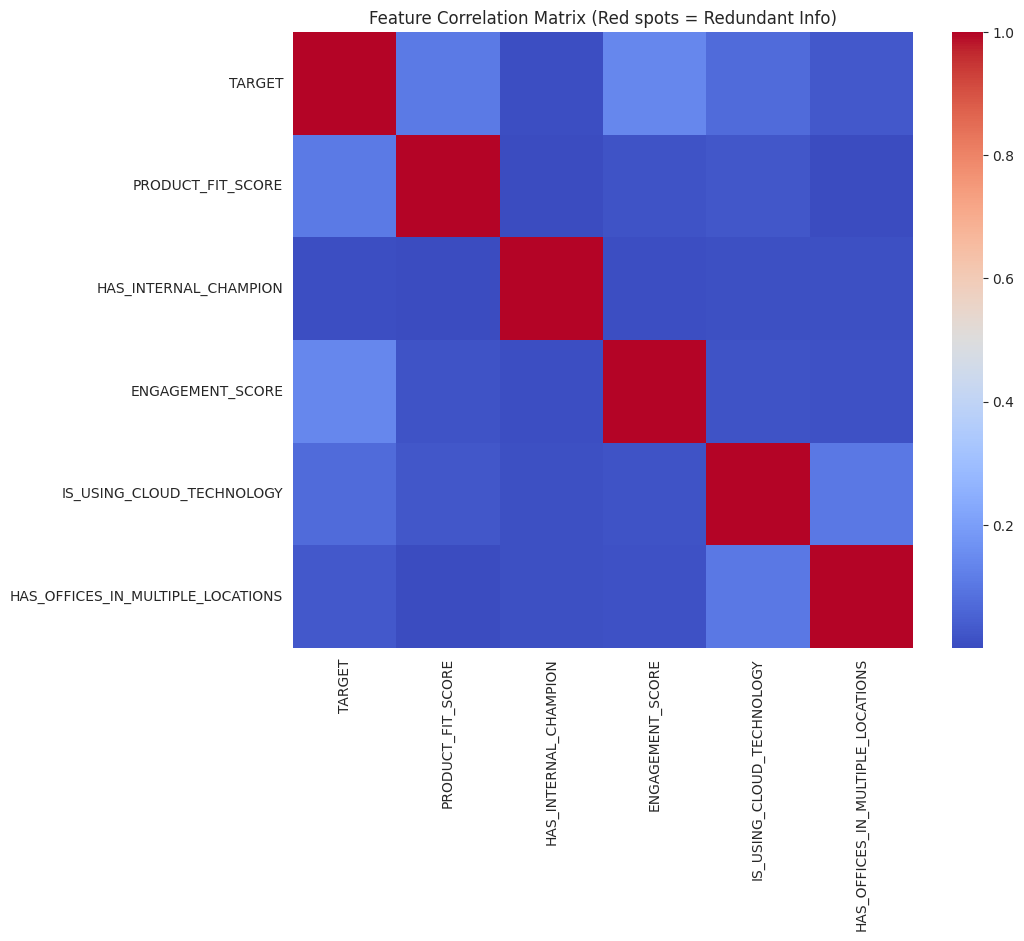

In [ ]:
import numpy as np
import seaborn as sns

# 4. Check for Duplicate Columns (Different Name, Same Content)
# We iterate through column pairs to safely check equality across mixed types
duplicate_pairs = []
cols = df_train.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        col1 = cols[i]
        col2 = cols[j]
        # equals() handles NaNs correctly (NaN == NaN is True here)
        if df_train[col1].equals(df_train[col2]):
            duplicate_pairs.append((col1, col2))

print("--- Duplicate Column Report ---")
if len(duplicate_pairs) > 0:
    print(f"Found {len(duplicate_pairs)} pairs of duplicate columns:")
    for c1, c2 in duplicate_pairs:
        print(f" - '{c2}' is identical to '{c1}'")
else:
    print("No columns with identical content found.")


# 5. Check for Highly Correlated Features (Redundant Information)
# Sometimes columns aren't EXACTLY the same, but provide the same signal (Correlation = 1.0)
# Select only numeric columns for correlation check
numeric_df = df_train.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95 (Highly Redundant)
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"\nHighly Correlated Features (>0.95): {to_drop}")

# Visualization of Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix (Red spots = Redundant Info)')
plt.show()

In [ ]:
#--- Drop Noisy Features ---

# Save the Test Account IDs for your final submission file later
test_ids = df_test['ACCOUNT_ID']

# List of columns to drop
# 1. DATASET: Just an indicator of source (train/test)
# 2. LINKED_FOLLOWER_RANGE: High noise/redundant
# 3. ACCOUNT_ID: Unique identifier, not predictive
cols_to_drop = ['DATASET', 'LINKED_FOLLOWER_RANGE']

# Drop from Train and Test
df_train = df_train.drop(columns=cols_to_drop, errors='ignore')
df_test = df_test.drop(columns=cols_to_drop, errors='ignore')

print(f"Dropped columns: {cols_to_drop}")
print(f"Final Train Shape: {df_train.shape}")
print(f"Final Test Shape:  {df_test.shape}")

Dropped columns: ['DATASET', 'LINKED_FOLLOWER_RANGE']
Final Train Shape: (10000, 21)
Final Test Shape:  (10000, 20)


### 1.5 Preprocessing & Cleaning Block

In [ ]:
import pandas as pd
import numpy as np
import re

# --- 1. DEFINE THE HELPERS ---

def fix_date_corruption(x):
    s = str(x)
    # If Excel corrupted "1-5" into "Jan-05" or "2026-01-05"
    if '01-05' in s or 'Jan-05' in s: return '1-5'
    if '01-09' in s or 'Jan-09' in s: return '1-9'
    return x

def parse_range_feature(x):
    if pd.isna(x) or str(x).lower() in ['unknown', 'nan', '']: return np.nan
    x = str(x).upper()

    # Simple multiplier map
    multipliers = {'K': 1000, 'M': 1_000_000, 'B': 1_000_000_000}

    def get_value(num_str):
        clean = re.sub(r'[$,<> ]', '', num_str)
        try:
            for suffix, mult in multipliers.items():
                if suffix in clean:
                    return float(clean.replace(suffix, '')) * mult
            return float(clean)
        except: return np.nan

    try:
        if '-' in x: # Handle "100-500"
            parts = x.split('-')
            return (get_value(parts[0]) + get_value(parts[1])) / 2
        elif '>' in x: # Handle ">$1B"
            return get_value(x) * 1.2
        elif '<' in x: # Handle "<$10K"
            return get_value(x) / 2
        else: # Handle "500"
            return get_value(x)
    except:
        return np.nan

# --- 2. DEFINE THE TARGET COLUMNS ---
# This includes the list you gave, PLUS the "Ghost" column 'LINKED_FOLLOWER_RANGE'
# visible in your output.
cols_to_process = [
    'REVENUE_RANGE',
    'EMPLOYEE_COUNT',
    'DATA_ANALYTICS_EMPLOYEES_RANGE',
    'ENGINEERING_EMPLOYEES_RANGE',
    'FINANCE_EMPLOYEES_RANGE',
    'MARKETING_EMPLOYEES_RANGE',
    'OPEN_JOB_POSTS_RANGE',
    'ESTIMATED_MONTHLY_IT_SPEND_RANGE',
    'LINKEDIN_FOLLOWERS_RANGE'
]

# --- 3. EXECUTE: FIX -> PARSE -> DROP ---
print("Starting conversion...")
def process_ranges(df):
  df_out = df.copy()
  for col in cols_to_process:
      if col in df_out.columns:
          # A. Create the new _NUM column with Fixed & Parsed data
          df_out[col + '_NUM'] = df_out[col].apply(fix_date_corruption).apply(parse_range_feature).fillna(-1)

  # Drop the original text columns
  df_out = df_out.drop(columns=cols_to_process, errors='ignore')
  return df_out


# Apply to BOTH datasets
print("Processing Training Data...")
df_train = process_ranges(df_train)

print("Processing Test Data...")
df_test = process_ranges(df_test)

# --- 4. VERIFY ---
print(f"\nFinal Train Shape: {df_train.shape}")
print(f"Final Test Shape:  {df_test.shape}")


Starting conversion...
Processing Training Data...
Processing Test Data...

Final Train Shape: (10000, 21)
Final Test Shape:  (10000, 20)


In [ ]:
import pandas as pd

# 1. Label Encoding for DEAL_COMPLEXITY (Preserving Order)
# Mapping manually ensures 'High' is greater than 'Low'
complexity_map = {'Low': 0, 'Medium': 1, 'High': 2}

# Apply to both Train and Test
df_train['DEAL_COMPLEXITY_ENCODED'] = df_train['DEAL_COMPLEXITY'].map(complexity_map)
df_test['DEAL_COMPLEXITY_ENCODED'] = df_test['DEAL_COMPLEXITY'].map(complexity_map)

# Fill any NaNs if new categories appear (optional safety)
df_train['DEAL_COMPLEXITY_ENCODED'] = df_train['DEAL_COMPLEXITY_ENCODED'].fillna(-1)
df_test['DEAL_COMPLEXITY_ENCODED'] = df_test['DEAL_COMPLEXITY_ENCODED'].fillna(-1)


# 2. One-Hot Encoding for SALES_GEO, PUBLIC_PRIVATE_COMPANY, INDUSTRY
cols_to_encode = ['SALES_GEO', 'PUBLIC_PRIVATE_COMPANY', 'INDUSTRY']

# Apply get_dummies
df_train_encoded = pd.get_dummies(df_train, columns=cols_to_encode, prefix=cols_to_encode)
df_test_encoded = pd.get_dummies(df_test, columns=cols_to_encode, prefix=cols_to_encode)

# 4. Drop original string columns that were encoded (if get_dummies didn't already)
# Note: get_dummies usually drops the original columns automatically.
# We should also drop the original DEAL_COMPLEXITY now that we have the ENCODED version.
df_train_final = df_train_encoded.drop(columns=['DEAL_COMPLEXITY'], errors='ignore')
df_test_final = df_test_encoded.drop(columns=['DEAL_COMPLEXITY'], errors='ignore')

In [ ]:
# Check the result
print(f"New Training Shape: {df_train_final.shape}")
print(f"New Test Shape: {df_test_final.shape}")
# Transpose the head so rows become columns
display(df_train_final.head().T)

New Training Shape: (10000, 35)
New Test Shape: (10000, 35)


,0,1,2,3,4
TARGET,1,1,1,1,1
ACCOUNT_ID,46f19851053b146305d72bfbe5c4f62de32cd2941dc2d5...,52a1c89b31df676fed6168afbbbf699ddfb1f286df6857...,26e0f5374b1faba5bb972a98965b88ec083e58dad3aba5...,1fa9d424f1576e19a30999af8458a461e9d94dbb7ca498...,94a39f77f4819fcdf6856e0b347a302ef07a90913316d1...
PRODUCT_FIT_SCORE,68,36,50,44,81
HAS_INTERNAL_CHAMPION,0,1,0,1,0
ENGAGEMENT_SCORE,62,42,82,73,69
IS_VALID_WEBSITE,True,True,True,True,True
IS_USING_CLOUD_TECHNOLOGY,1.0,0.0,1.0,1.0,1.0
HAS_OFFICES_IN_MULTIPLE_LOCATIONS,0.0,0.0,0.0,1.0,0.0
REVENUE_RANGE_NUM,30000000.0,5000000.0,75000000.0,375000000.0,1200000000.0
EMPLOYEE_COUNT_NUM,749.5,5.0,749.5,2950.0,7450.0


In [ ]:
# --- 1. Separate IDs and Target ---
train_ids = df_train_final['ACCOUNT_ID']
test_ids  = df_test_final['ACCOUNT_ID']
y_train   = df_train_final['TARGET']

# --- 2. Define Feature Matrix (X) ---
# Select all columns except ID and Target
feature_cols = [col for col in df_train_final.columns if col not in ['TARGET', 'ACCOUNT_ID']]

X_train = df_train_final[feature_cols]

# Create X_test and ensure it has the exact same columns as X_train
X_test = df_test_final.reindex(columns=feature_cols, fill_value=0)

# --- 3. Verify Shapes ---
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (10000, 33), y_train: (10000,)
X_test:  (10000, 33)


### 1.6 Analysing Data

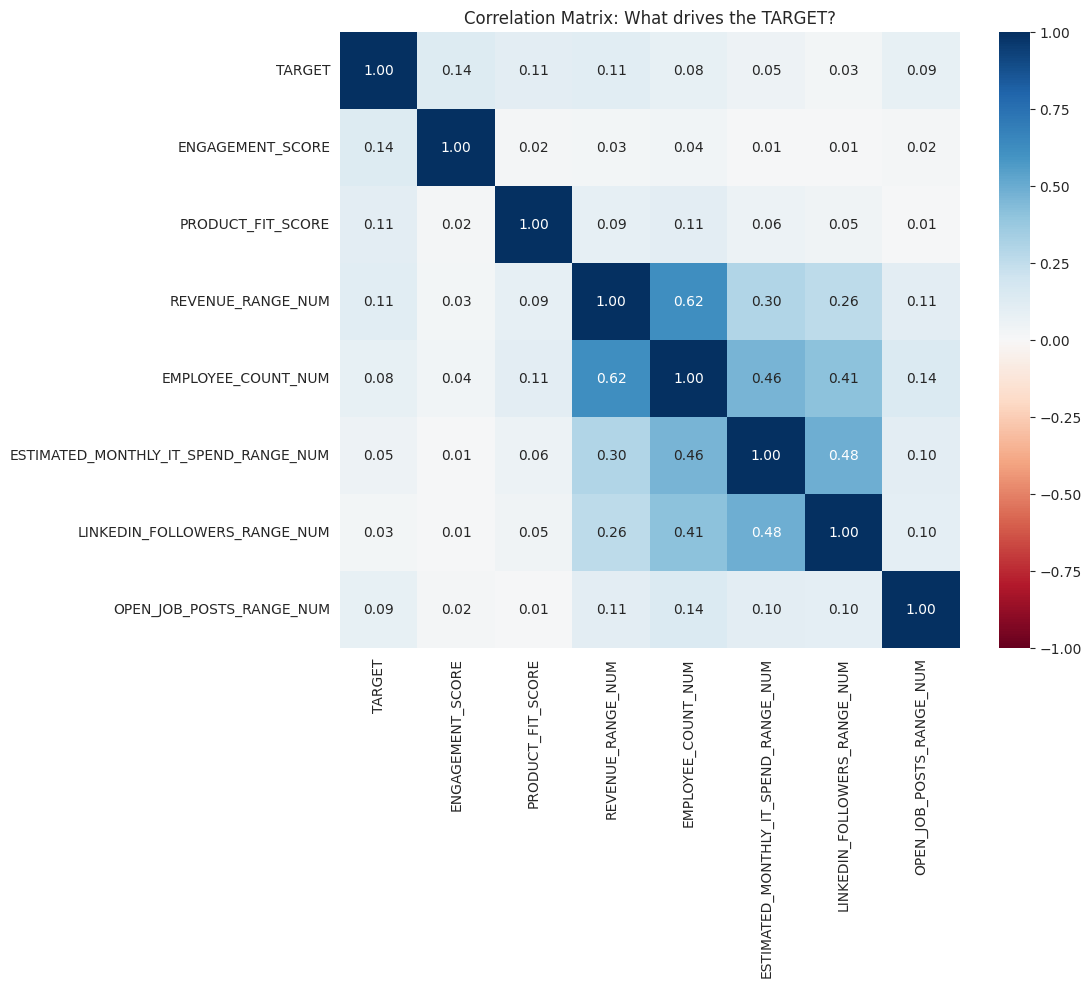

Correlation with TARGET:
TARGET                                  1.000000
ENGAGEMENT_SCORE                        0.140403
REVENUE_RANGE_NUM                       0.114085
PRODUCT_FIT_SCORE                       0.107731
OPEN_JOB_POSTS_RANGE_NUM                0.085123
EMPLOYEE_COUNT_NUM                      0.084463
ESTIMATED_MONTHLY_IT_SPEND_RANGE_NUM    0.051597
LINKEDIN_FOLLOWERS_RANGE_NUM            0.031063
Name: TARGET, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare a temporary dataframe for EDA
# We combine X and y just for this chart so we can see relationships
eda_df = X_train.copy()
eda_df['TARGET'] = y_train

# 2. Select specific numerical columns to keep the chart readable
# (We exclude the many Industry/Geo columns for a clearer view)
cols_to_check = [
    'TARGET',
    'ENGAGEMENT_SCORE',
    'PRODUCT_FIT_SCORE',
    'REVENUE_RANGE_NUM',
    'EMPLOYEE_COUNT_NUM',
    'ESTIMATED_MONTHLY_IT_SPEND_RANGE_NUM',
    'LINKEDIN_FOLLOWERS_RANGE_NUM',
    'OPEN_JOB_POSTS_RANGE_NUM'
]

# 3. Calculate Correlation Matrix
corr_matrix = eda_df[cols_to_check].corr()

# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix: What drives the TARGET?")
plt.show()

# 5. Print the exact correlation numbers for the Target
print("Correlation with TARGET:")
print(corr_matrix['TARGET'].sort_values(ascending=False))

## Model Development

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split

# --- 1. Internal Split (80% Train / 20% Validation) ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Training models... this may take a moment.")

# --- 2. Train Models (All Class-Balanced) ---

# A. Random Forest (Champion)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_tr)

# B. Gradient Boosting (Requires manual sample weights)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_tr)
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_model.fit(X_tr, y_tr, sample_weight=sample_weights)

# C. Logistic Regression (Linear Baseline)
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_tr, y_tr)

# D. Decision Tree (Simple Baseline)
dt_model = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
dt_model.fit(X_tr, y_tr)

# --- 3. Calculate Scores ---
rf_auc = roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1])
gb_auc = roc_auc_score(y_val, gb_model.predict_proba(X_val)[:, 1])
lr_auc = roc_auc_score(y_val, lr_model.predict_proba(X_val)[:, 1])
dt_auc = roc_auc_score(y_val, dt_model.predict_proba(X_val)[:, 1])

# --- 4. Final Leaderboard ---
print(f"\n--- Model Leaderboard (AUC-ROC) ---")
print(f"1. Random Forest:      {rf_auc:.4f}")
print(f"2. Gradient Boosting:  {gb_auc:.4f}")
print(f"3. Logistic Regression:{lr_auc:.4f}")
print(f"4. Decision Tree:      {dt_auc:.4f}")

# --- 5. Detailed Report for Champion (Random Forest) ---
print("\n--- Champion Model Details (Random Forest) ---")
y_val_pred = rf_model.predict(X_val)
print(classification_report(y_val, y_val_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Training models... this may take a moment.

--- Model Leaderboard (AUC-ROC) ---
1. Random Forest:      0.7359
2. Gradient Boosting:  0.7316
3. Logistic Regression:0.5744
4. Decision Tree:      0.6945

--- Champion Model Details (Random Forest) ---
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1800
           1       0.23      0.30      0.26       200

    accuracy                           0.83      2000
   macro avg       0.58      0.59      0.58      2000
weighted avg       0.85      0.83      0.84      2000

Confusion Matrix:
[[1601  199]
 [ 140   60]]


##Evaluation

In [ ]:
y_val_probs = rf_model.predict_proba(X_val)[:, 1]

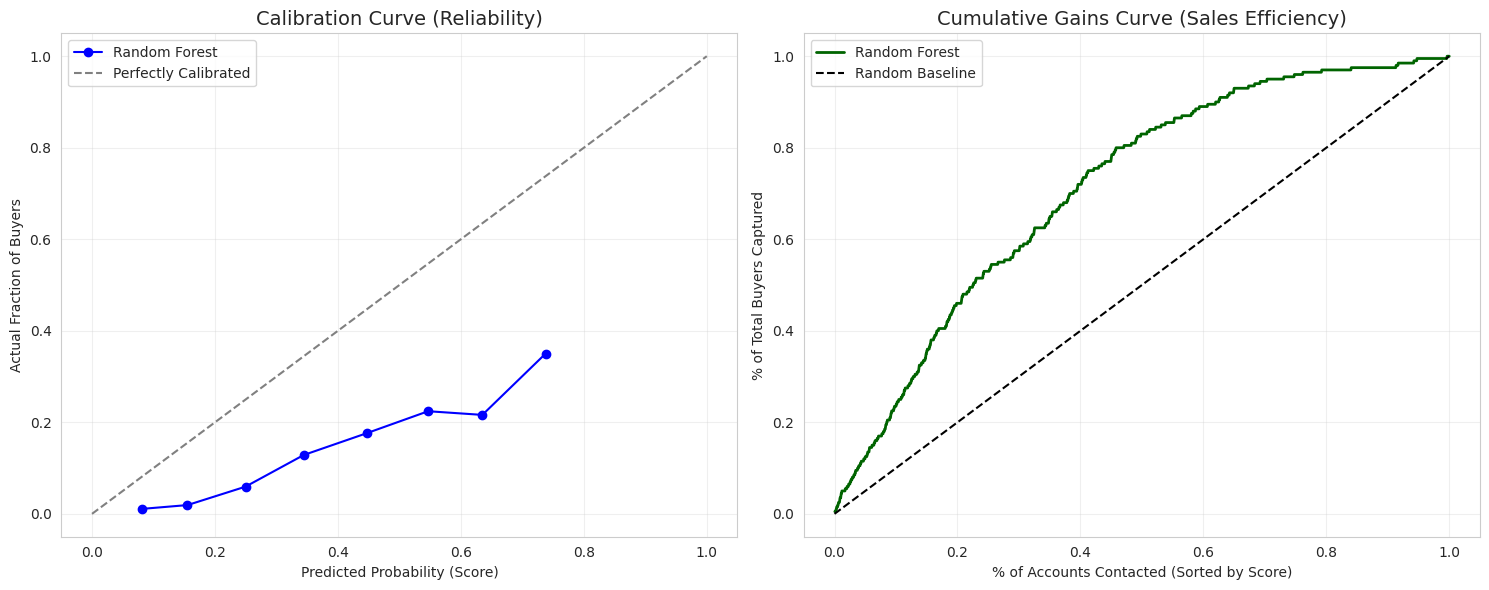

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.calibration import calibration_curve

# --- 1. Calibration Curve ---
# This checks: When the model says "70% chance", is it actually 70%?
prob_true, prob_pred = calibration_curve(y_val, y_val_probs, n_bins=10)

plt.figure(figsize=(15, 6))

# Plot A: Calibration
plt.subplot(1, 2, 1)
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest', color='blue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title("Calibration Curve (Reliability)", fontsize=14)
plt.xlabel("Predicted Probability (Score)")
plt.ylabel("Actual Fraction of Buyers")
plt.legend()
plt.grid(True, alpha=0.3)

# --- 2. Cumulative Gains Curve (The "Money Slide") ---
# Step A: Create a DataFrame with Actuals and Probs
y_val_probs = rf_model.predict_proba(X_val)[:, 1]
df_gain = pd.DataFrame({
    'actual': y_val,
    'prob': y_val_probs
})

# Step B: Sort by probability (High to Low) - mimicking a Sales Rep calling the best leads first
df_gain = df_gain.sort_values(by='prob', ascending=False)

# Step C: Calculate cumulative sums
cum_actuals = np.cumsum(df_gain['actual'])
cum_percentages = cum_actuals / df_gain['actual'].sum() # Y-Axis: % of Total Buyers Captured
population_percentages = np.arange(1, len(df_gain) + 1) / len(df_gain) # X-Axis: % of Accounts Contacted

# Plot B: Cumulative Gains
plt.subplot(1, 2, 2)
plt.plot(population_percentages, cum_percentages, label='Random Forest', color='darkgreen', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline') # Diagonal line
plt.title("Cumulative Gains Curve (Sales Efficiency)", fontsize=14)
plt.xlabel("% of Accounts Contacted (Sorted by Score)")
plt.ylabel("% of Total Buyers Captured")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipython-input-674020089.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


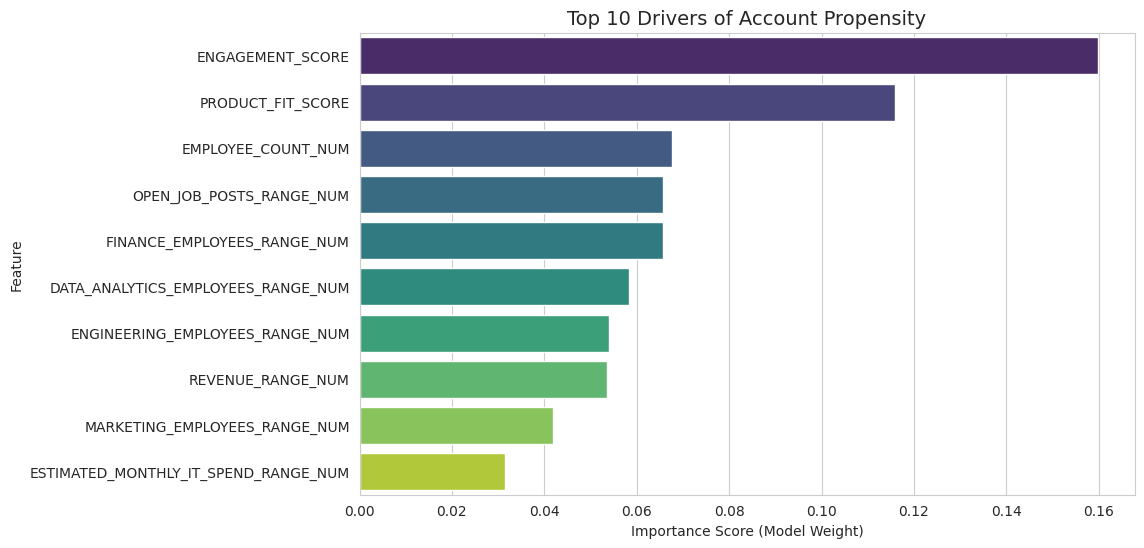

Top 5 Drivers (For Presentation):
                        Feature  Importance
2              ENGAGEMENT_SCORE    0.159765
0             PRODUCT_FIT_SCORE    0.115966
7            EMPLOYEE_COUNT_NUM    0.067672
12     OPEN_JOB_POSTS_RANGE_NUM    0.065794
10  FINANCE_EMPLOYEES_RANGE_NUM    0.065759


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Extract Feature Importances ---
# This asks the Random Forest: "Which columns helped you decide the most?"
importances = rf_model.feature_importances_
feature_names = X_train.columns

# --- 2. Create a DataFrame for plotting ---
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- 3. Plot Top 10 Drivers ---
plt.figure(figsize=(10, 6))
# Using 'viridis' palette for a professional look
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')

plt.title("Top 10 Drivers of Account Propensity", fontsize=14)
plt.xlabel("Importance Score (Model Weight)")
plt.ylabel("Feature")
plt.show()

# --- 4. Print for Report ---
print("Top 5 Drivers (For Presentation):")
print(feature_imp_df.head(5))

## Scoring

In [ ]:
# --- 1. Predict & Score ---
# Get probabilities for class 1 (Buyers)
test_probs = rf_model.predict_proba(X_test)[:, 1]
# Convert to integer score (0-100)
test_aps = (test_probs * 100).round(0).astype(int)

# --- 2. Define Buckets (Business Logic) ---
def get_tier(score):
    if score >= 50: return 'Tier 1: Hot (Call Now)'
    elif score >= 30: return 'Tier 2: Warm (Nurture)'
    else: return 'Tier 3: Cold (Ignore)'

# --- 3. Create Submission DataFrame ---
submission_df = pd.DataFrame({
    'account_id': test_ids,            # Lowercase to match requirements
    'predicted_probability': test_probs,
    'APS_score': test_aps
})

# Add the Tiers (Optional but great for the "Business Interpretation" part)
submission_df['Propensity_Tier'] = submission_df['APS_score'].apply(get_tier)

# --- 4. Save & Verify ---
submission_df.to_csv('submission.csv', index=False)

print("✅ Submission File 'submission.csv' Created Successfully!")
print(f"File Shape: {submission_df.shape}")
print("\n--- Tier Distribution (How many leads in each bucket?) ---")
print(submission_df['Propensity_Tier'].value_counts())

# Preview
print("\n--- Preview ---")
print(submission_df.head())

✅ Submission File 'submission.csv' Created Successfully!
File Shape: (10000, 4)

--- Tier Distribution (How many leads in each bucket?) ---
Propensity_Tier
Tier 3: Cold (Ignore)     5249
Tier 2: Warm (Nurture)    3441
Tier 1: Hot (Call Now)    1310
Name: count, dtype: int64

--- Preview ---
                                          account_id  predicted_probability  \
0  75ee65bd7b2c855bb6d2624f59c91ce8e72db879e582fd...               0.211810   
1  93078f10242fec60fbaff5d56aeb91b4d5436771db1264...               0.495541   
2  cafd9546a85b8f322b712a9526548bf9375f10f4537aba...               0.285264   
3  6b2cf13ba0048aafcc5756890e56d47999cfbcdc74b126...               0.216207   
4  157e50d605e1ca9ff328e16fe19eb9982348cc1dc7a2ea...               0.218642   

   APS_score         Propensity_Tier  
0         21   Tier 3: Cold (Ignore)  
1         50  Tier 1: Hot (Call Now)  
2         29   Tier 3: Cold (Ignore)  
3         22   Tier 3: Cold (Ignore)  
4         22   Tier 3: Cold (Ignore)  